In [17]:
import os
import scipy as sp
import matplotlib.pyplot as plt
import numpy as np
import skimage
from PIL import Image

In [5]:
sample_path = "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/SAMPLE/mat_files/real/m1"

In [6]:
ds1 = sorted(os.listdir(sample_path))[11]

In [7]:
ds1

'm1_real_A_elevDeg_014_azCenter_022_18_serial_0ap00n.mat'

In [8]:
sp.io.loadmat(os.path.join(sample_path, ds1))

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Tue Jun 18 13:08:07 2019',
 '__version__': '1.0',
 '__globals__': [],
 'aligned': array([[1]], dtype=uint8),
 'azimuth': array([[22.183182]]),
 'bandwidth': array([[591000000]], dtype=int32),
 'center_freq': array([[9.6e+09]]),
 'complex_img': array([[-0.03060263-0.02418613j, -0.02513243-0.02868763j,
         -0.01485388-0.01329767j, ...,  0.02770008-0.00144602j,
          0.00684021-0.00375115j, -0.03173195-0.00883384j],
        [-0.04944967-0.04737008j, -0.04780082-0.00844538j,
         -0.01946136+0.02439281j, ...,  0.02767113+0.00724789j,
          0.012367  -0.01451593j, -0.02221692-0.05271909j],
        [-0.03097881-0.02224708j, -0.03672392-0.00637221j,
         -0.02032193+0.05625132j, ...,  0.02600486-0.03891905j,
         -0.01451349-0.06069903j, -0.01700965-0.04730986j],
        ...,
        [ 0.00275167-0.03195357j,  0.03837933-0.02828197j,
          0.03256701+0.00906631j, ..., -0.03113071+0.00215235j,
   

In [9]:
complex_img = sp.io.loadmat(os.path.join(sample_path, ds1))["complex_img"]

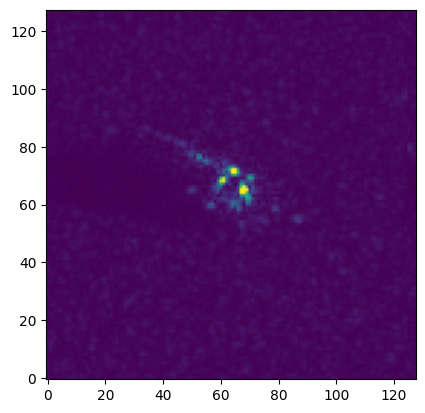

In [10]:
plt.imshow(np.abs(complex_img), vmin = 0, vmax = 2.5, origin = "lower")

In [11]:
phase_hist = np.fft.fftshift(np.fft.fft2(complex_img))

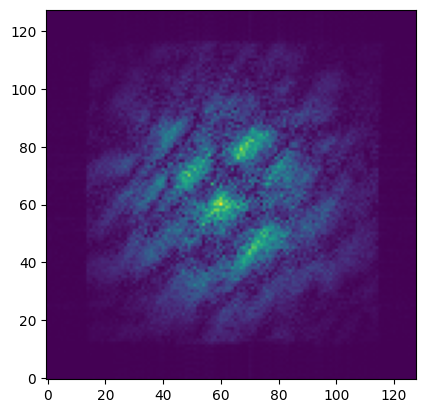

In [12]:
plt.imshow(np.abs(phase_hist), origin = "lower")

In [13]:
upscaled_phase_hist = np.pad(phase_hist, pad_width = ((30, 30), (30, 30)), constant_values = 0)

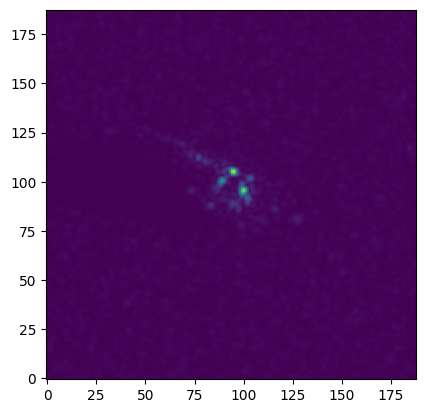

In [14]:
plt.imshow(
    np.abs(np.fft.ifft2(np.fft.ifftshift(upscaled_phase_hist))), 
    vmin = 0, 
    vmax = 2.5,
    origin = "lower")

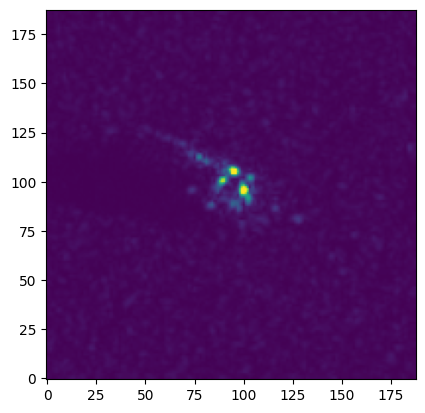

In [15]:
rt = skimage.transform.resize(np.abs(complex_img), (188, 188), anti_aliasing = False)
plt.imshow(rt,
    vmin = 0, 
    vmax = 2.5,
    origin = "lower")

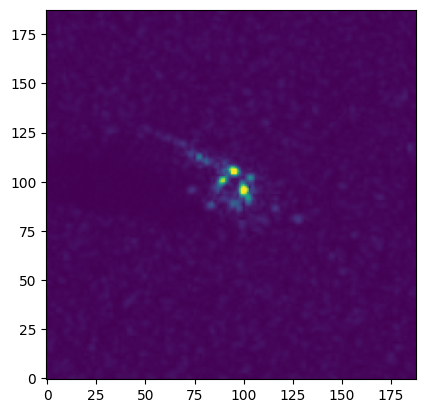

In [19]:
naive_img = Image.fromarray(np.abs(complex_img))
naive_img_resized = naive_img.resize((188, 188), resample=Image.BILINEAR)
plt.imshow(np.array(naive_img_resized), vmin = 0, vmax = 2.5, origin = "lower")